# Rule of Law K-Medoids Clean Pipeline
This notebook runs a compact end-to-end pipeline from data cleaning to cluster interpretation outputs.

## Step 0: Setup and Global Controls

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PATH_DATA = "OmnibusW1_November2025_UOFI.STAT427.xlsx"
K_CHOSEN = 3
MIN_DURATION_MIN = 2.0
UNKNOWN_CODE = 3
HEARD_FILTER_MODE = "yes"
APPLY_HEARD_FILTER = True

CONCEPT_COLS = [
    "NoOneAbove","Obey","Enforce","EveryoneObey","WayToFix",
    "Prospective","Clear","Consistent","Possible","Stable",
    "AsWritten","Knowable","SeparationPowers","RightsOfAccused",
    "AccessToLawyers","JudicialIndependence","AccessToCourts",
    "Respect","FairProcedures","Voice","NoProtest","Property",
    "WithoutCourt","CrimeControl","NoSelfDealing","EconGrowth",
    "Contracts","HumanRights","Majority","InnocentUntilProve",
    "TreatsEqual","DisputesInCourt","TrustAuthorities","Military",
    "RightToVote","WealthGap",
]

DEMO_VARS = [
    "SEX","AGE4","AGE7","RACETHNICITY","EDUC5","INCOME4","REGION4","REGION9","HHSIZE",
    "IDEO","PartyID5","PartyID7","HeardOf","NewsFreq","NEWSCONS","SURV_MODE","Device",
    "SURV_LANG","METRO","INTERNET"
]

assert os.path.exists(PATH_DATA), f"Data file not found: {PATH_DATA}"

## Step 1: Data Cleaning and Analysis Base
This step prepares concept variables, removes records at or below the duration threshold, and applies optional HeardOf filtering.

In [2]:
df = pd.read_excel(PATH_DATA)
CONCEPT_COLS = [c for c in CONCEPT_COLS if c in df.columns]
DEMO_VARS = [v for v in DEMO_VARS if v in df.columns]

X = (
    df[CONCEPT_COLS]
    .replace(["#NULL!"], np.nan)
    .apply(pd.to_numeric, errors="coerce")
    .replace({77: np.nan, 98: np.nan, 99: np.nan, -1: np.nan})
)

dur = pd.to_numeric(df["duration_UOFI"], errors="coerce")
keep_duration = dur > MIN_DURATION_MIN

meta = df.loc[keep_duration].copy()
X = X.loc[keep_duration].copy()
meta["duration_UOFI"] = dur.loc[keep_duration]
meta["WEIGHT_GP"] = pd.to_numeric(meta.get("WEIGHT_GP", 1.0), errors="coerce").fillna(1.0)

if APPLY_HEARD_FILTER and "HeardOf" in meta.columns:
    heard = pd.to_numeric(meta["HeardOf"], errors="coerce")
    if HEARD_FILTER_MODE == "yes":
        mask = heard.eq(1)
    elif HEARD_FILTER_MODE == "no":
        mask = heard.eq(2)
    else:
        mask = heard.notna()
    meta = meta.loc[mask].copy()
    X = X.loc[mask].copy()

print(f"Rows after duration filter (> {MIN_DURATION_MIN} min): {keep_duration.sum()}")
print(f"Rows in analysis set: {len(meta)}")

Rows after duration filter (> 2.0 min): 962
Rows in analysis set: 721


## Step 2: K-Medoids with Custom Gower-Style Distance
This step builds clusters using a DK-excluded pairwise distance matrix and assigns cluster labels for downstream analysis.

In [3]:
X_num = X.astype(float)
X_map = X_num.replace({1: 0.0, 2: 1.0, 4: 2.0, 5: 3.0, 3: np.nan})
A = X_map.to_numpy()

n, p = A.shape
D_sum = np.zeros((n, n), dtype=float)
W = np.zeros((n, n), dtype=float)

for k in range(p):
    col = A[:, k]
    idx = np.where(np.isfinite(col))[0]
    if idx.size < 2:
        continue
    v = col[idx]
    diff = np.abs(v[:, None] - v[None, :]) / 3.0
    D_sum[np.ix_(idx, idx)] += diff
    W[np.ix_(idx, idx)] += 1.0

D_custom = np.ones((n, n), dtype=float)
np.divide(D_sum, W, out=D_custom, where=W > 0)
np.fill_diagonal(D_custom, 0.0)

kmed = KMedoids(n_clusters=K_CHOSEN, metric="precomputed", init="k-medoids++", random_state=RANDOM_STATE)
clusters = kmed.fit_predict(D_custom)
meta = meta.copy()
meta["cluster_concept"] = clusters.astype(int)

sil = silhouette_score(D_custom, clusters, metric="precomputed")
print("Silhouette:", round(float(sil), 4))
print(meta["cluster_concept"].value_counts().sort_index())

Silhouette: 0.2359
cluster_concept
0    253
1    436
2     32
Name: count, dtype: int64


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


## Step 3: Demographics Screening and Multinomial Logit
This step screens demographic variables against cluster membership and models cluster propensities with multinomial logistic regression.

Demographic screen


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,var,chi2,df,p_value,cramers_v,p_fdr_bh
13,NEWSCONS,123.569751,42,5.806507e-10,0.303896,1.045171e-08
4,EDUC5,53.106686,8,1.028384e-08,0.199225,9.255457e-08
8,HHSIZE,45.322143,10,1.902171e-06,0.184045,1.141303e-05
9,IDEO,41.023742,10,1.117548e-05,0.175100,5.028966e-05
12,NewsFreq,47.488415,14,1.597072e-05,0.188392,5.749458e-05
5,INCOME4,29.941014,6,4.033650e-05,0.149590,1.210095e-04
6,REGION4,24.367790,6,4.468385e-04,0.134951,1.149013e-03
3,RACETHNICITY,26.951360,10,2.650881e-03,0.141925,5.964482e-03
7,REGION9,34.483121,16,4.674191e-03,0.160536,9.348381e-03
1,AGE4,15.682355,6,1.556434e-02,0.108262,2.801582e-02


Selected demographics: ['NEWSCONS', 'EDUC5', 'HHSIZE', 'IDEO', 'NewsFreq', 'INCOME4', 'REGION4', 'RACETHNICITY', 'REGION9', 'AGE4', 'METRO', 'Device']
MNLogit in-sample accuracy: 0.644


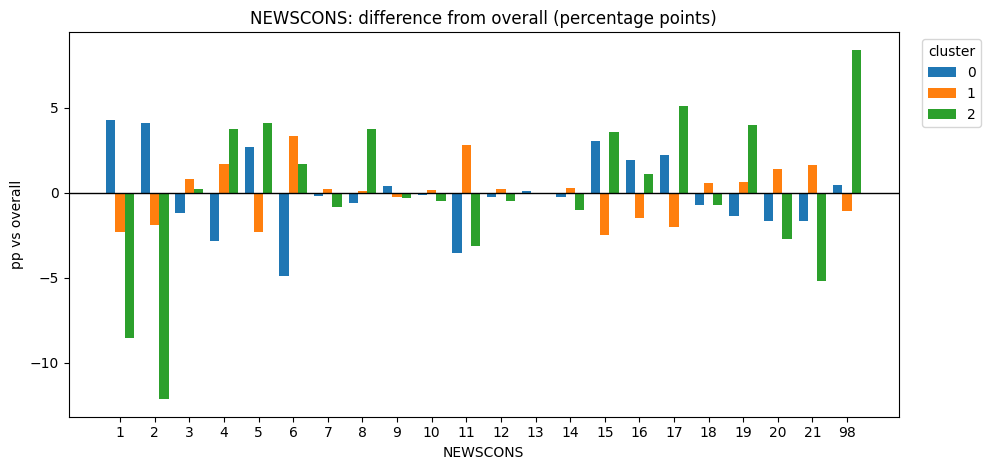

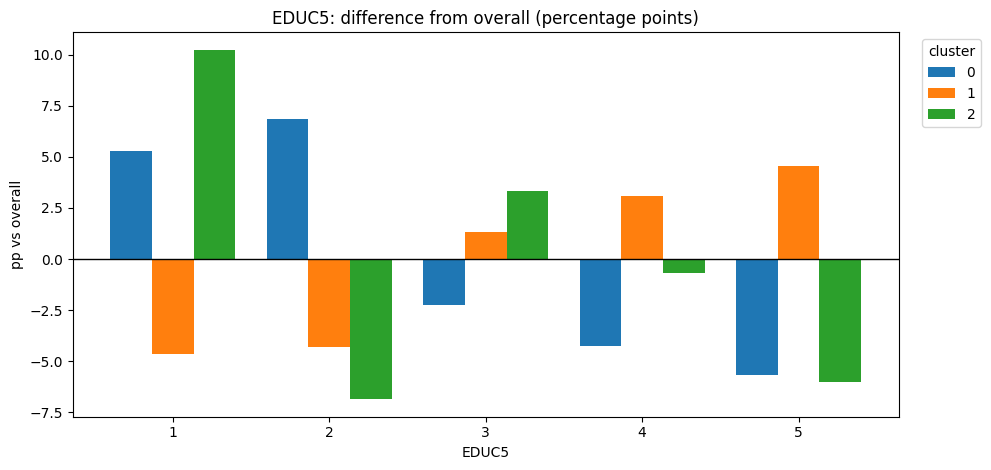

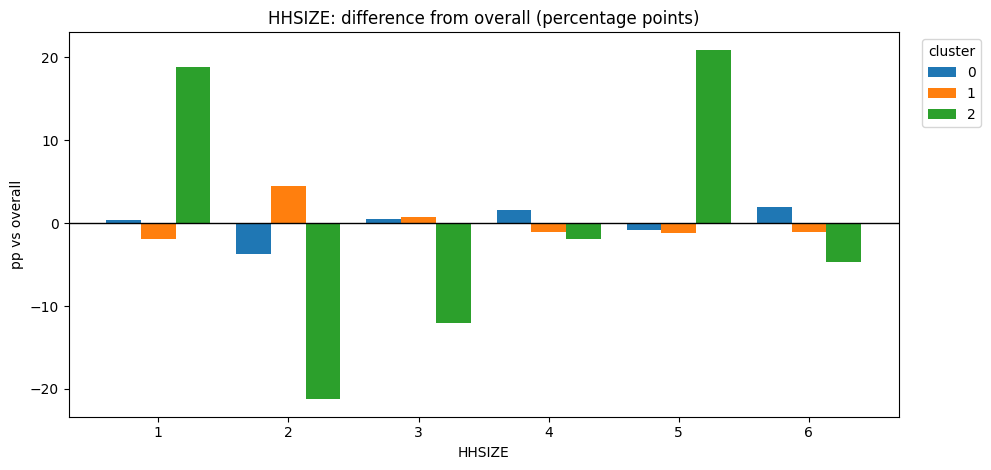

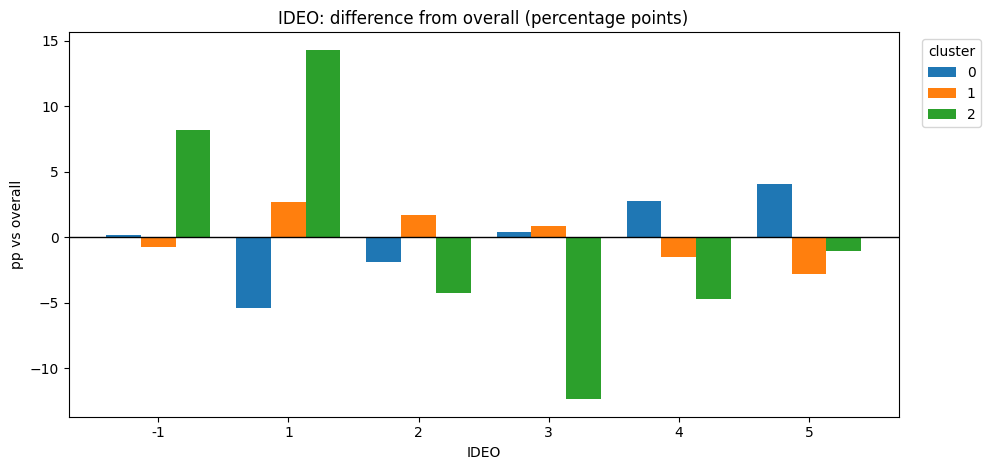

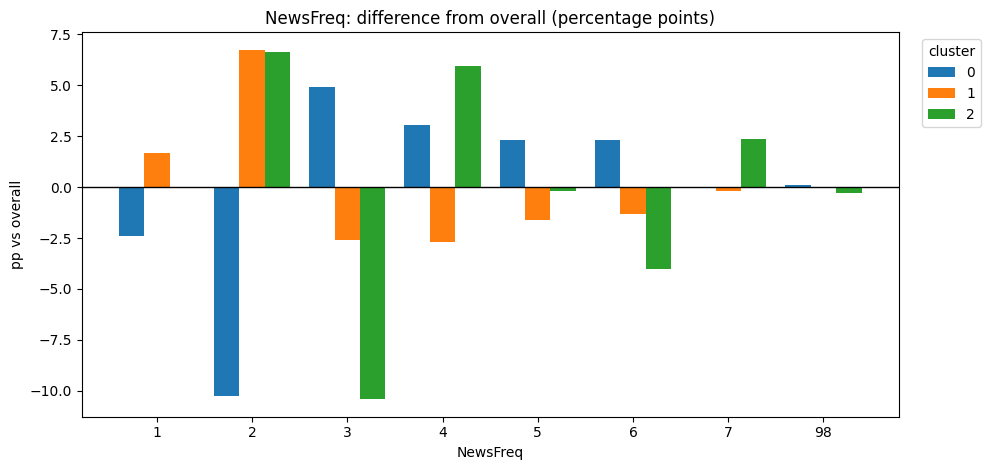

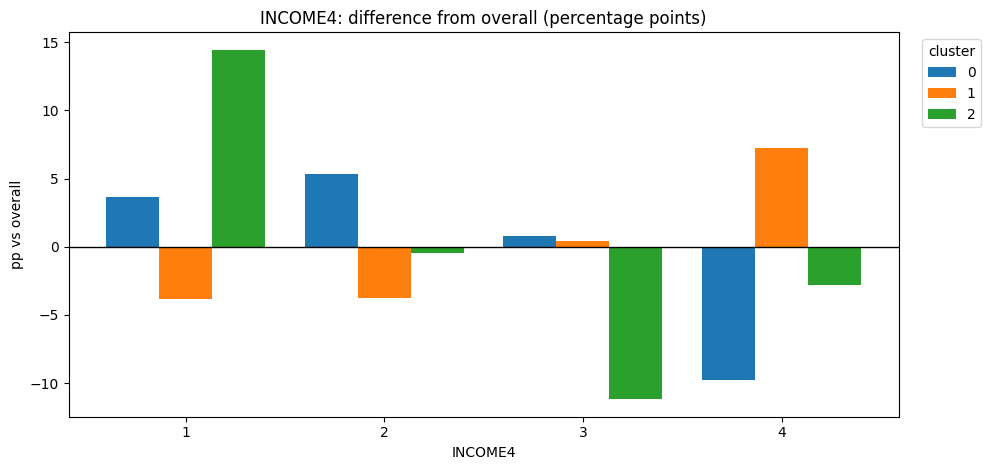

In [4]:
cluster_col = "cluster_concept"
wcol = "WEIGHT_GP"

rows = []
for v in DEMO_VARS:
    d = meta[[cluster_col, v, wcol]].dropna()
    if d.empty or d[v].nunique() < 2:
        continue
    tab = pd.crosstab(d[cluster_col], d[v], values=d[wcol], aggfunc="sum").fillna(0)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(tab)
    n = tab.to_numpy().sum()
    r, c = tab.shape
    vcr = np.sqrt((chi2 / n) / max(min(r - 1, c - 1), 1))
    rows.append({"var": v, "chi2": chi2, "df": dof, "p_value": pval, "cramers_v": vcr})

demo_screen = pd.DataFrame(rows).sort_values("p_value") if rows else pd.DataFrame(columns=["var","chi2","df","p_value","cramers_v"])
if not demo_screen.empty:
    demo_screen["p_fdr_bh"] = multipletests(demo_screen["p_value"], method="fdr_bh")[1]
else:
    demo_screen["p_fdr_bh"] = []

demo_sig = demo_screen.loc[demo_screen["p_fdr_bh"] < 0.05, "var"].tolist() if not demo_screen.empty else []
X_demo = pd.get_dummies(meta[demo_sig], drop_first=True, dummy_na=False) if len(demo_sig) else pd.DataFrame(index=meta.index)

pred_demo = np.repeat(meta[cluster_col].mode().iloc[0], len(meta))
for k in range(K_CHOSEN):
    meta[f"propensity_cluster_{k}"] = 0.0

if X_demo.shape[1] > 0:
    X_demo = X_demo.apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(float)
    nunique = X_demo.nunique(dropna=False)
    X_demo = X_demo.loc[:, nunique > 1]

if X_demo.shape[1] > 0:
    X_demo = sm.add_constant(X_demo, has_constant="add")
    y_demo = meta[cluster_col].astype(int)
    try:
        mnlogit = sm.MNLogit(y_demo, X_demo).fit(method="lbfgs", maxiter=800, disp=False)
        p_demo = np.asarray(mnlogit.predict(X_demo), dtype=float)
        pred_demo = p_demo.argmax(axis=1)
        for k in range(min(K_CHOSEN, p_demo.shape[1])):
            meta[f"propensity_cluster_{k}"] = p_demo[:, k]
    except Exception:
        pass

meta["pred_cluster_demo"] = pred_demo
print("Demographic screen")
display(demo_screen)
print("Selected demographics:", demo_sig)
print("MNLogit in-sample accuracy:", round(float((meta["pred_cluster_demo"] == meta[cluster_col]).mean()), 3))

vars_model = demo_sig[:10]
vars_plot = demo_sig[:6] if len(demo_sig) > 0 else vars_model[:6]

for v in vars_plot:
    d = meta[[cluster_col, v, wcol]].dropna().copy()
    if d.empty or d[v].nunique() <= 1:
        continue

    overall = d.groupby(v)[wcol].sum()
    overall = overall / overall.sum()

    tab = d.pivot_table(values=wcol, index=cluster_col, columns=v, aggfunc="sum", fill_value=0.0)
    tab = tab.div(tab.sum(axis=1), axis=0)

    pp = (tab - overall).fillna(0.0) * 100.0
    pp = pp.sort_index()

    cats = [str(c) for c in pp.columns]
    x = np.arange(len(cats))
    clus = pp.index.tolist()
    width = 0.8 / max(len(clus), 1)

    plt.figure(figsize=(10, 4.8))
    for i, cl in enumerate(clus):
        plt.bar(
            x + (i - (len(clus) - 1) / 2) * width,
            pp.loc[cl].values,
            width=width,
            label=str(cl),
        )

    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(x, cats)
    plt.xlabel(v)
    plt.ylabel("pp vs overall")
    plt.title(f"{v}: difference from overall (percentage points)")
    plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Step 4: Concept Item Differentiation Across Clusters
This step tests each concept question across clusters and ranks items by how strongly they differentiate groups.

In [5]:
item_rows = []
for c in CONCEPT_COLS:
    d = pd.DataFrame({"cluster": meta["cluster_concept"], "x": pd.to_numeric(X[c], errors="coerce")}).dropna()
    if d.empty or d["x"].nunique() < 2:
        continue
    tab = pd.crosstab(d["cluster"], d["x"])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(tab)
    n = tab.to_numpy().sum()
    r, cc = tab.shape
    vcr = np.sqrt((chi2 / n) / max(min(r - 1, cc - 1), 1))
    item_rows.append({"item": c, "chi2": chi2, "df": dof, "p_value": pval, "cramers_v": vcr})

item_tests = pd.DataFrame(item_rows).sort_values("p_value") if item_rows else pd.DataFrame(columns=["item","chi2","df","p_value","cramers_v"])
if not item_tests.empty:
    item_tests["p_fdr_bh"] = multipletests(item_tests["p_value"], method="fdr_bh")[1]
else:
    item_tests["p_fdr_bh"] = []

print("Concept-item cluster differentiation ranking")
display(item_tests)

Concept-item cluster differentiation ranking


,item,chi2,df,p_value,cramers_v,p_fdr_bh
13,RightsOfAccused,544.910451,8,1.609622e-112,0.616007,5.794638e-111
27,HumanRights,425.621058,8,6.159227e-87,0.544420,1.108661e-85
4,WayToFix,413.400116,8,2.543867e-84,0.535802,3.052640e-83
14,AccessToLawyers,410.566488,8,1.027759e-83,0.535826,9.249831e-83
18,FairProcedures,401.686640,8,8.161659e-82,0.529260,5.876394e-81
16,AccessToCourts,397.756591,8,5.654994e-81,0.527032,3.392996e-80
12,SeparationPowers,388.889202,8,4.453863e-79,0.521489,2.290558e-78
3,EveryoneObey,369.478207,8,6.272251e-75,0.509735,2.822513e-74
29,InnocentUntilProve,367.956138,8,1.326134e-74,0.507259,5.304537e-74
2,Enforce,340.483356,8,9.720763e-69,0.487955,3.499475e-68


## Step 5: Respondent-Level and Propensity Summaries by Cluster
This step summarizes respondent-level scores and estimated demographic propensities for each cluster.

Confusion matrix


,pred_0,pred_1,pred_2
true_0,73,180,0
true_1,45,391,0
true_2,4,28,0


Accuracy by cluster


,cluster_concept,accuracy,n
0,0,0.288538,253
1,1,0.896789,436
2,2,0.000000,32


rol_pc1 summary by cluster


,cluster_concept,n,rol_pc1_mean,rol_pc1_sd
0,0,253,-1.994769,2.209303
1,1,436,1.722747,1.777580
2,2,32,-7.701286,2.491463


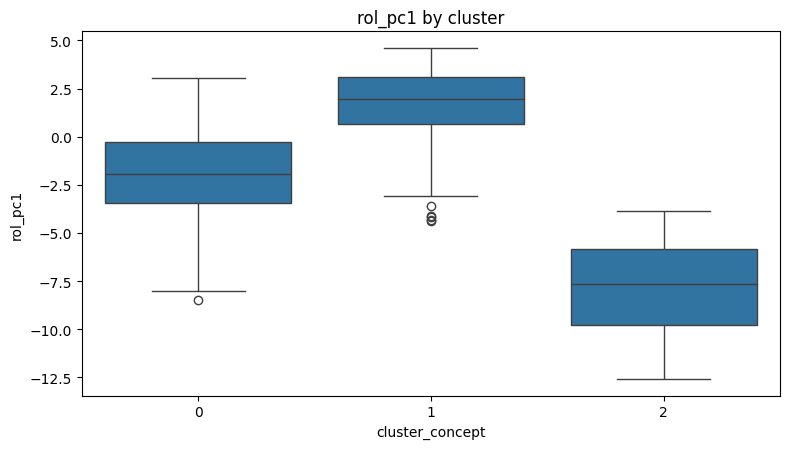

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

cluster_col = "cluster_concept"
pred_col = "pred_cluster_demo"

X_imp = X.apply(lambda s: s.fillna(s.median()))
Z = StandardScaler().fit_transform(X_imp)
rol_pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(Z).ravel()
meta = meta.copy()
meta["rol_pc1"] = rol_pc1

if pred_col in meta.columns:
    cm = confusion_matrix(meta[cluster_col].astype(int), meta[pred_col].astype(int), labels=sorted(meta[cluster_col].unique()))
    cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in sorted(meta[cluster_col].unique())], columns=[f"pred_{c}" for c in sorted(meta[cluster_col].unique())])
    print("Confusion matrix")
    display(cm_df)

    acc_rows = []
    for c in sorted(meta[cluster_col].unique()):
        m = meta[cluster_col].astype(int).eq(int(c))
        acc = (meta.loc[m, pred_col].astype(int) == int(c)).mean()
        acc_rows.append({"cluster_concept": int(c), "accuracy": float(acc), "n": int(m.sum())})
    acc_df = pd.DataFrame(acc_rows)
    print("Accuracy by cluster")
    display(acc_df)

summary_df = (
    meta.groupby(cluster_col)["rol_pc1"]
    .agg(n="count", rol_pc1_mean="mean", rol_pc1_sd="std")
    .reset_index()
    .sort_values(cluster_col)
)
print("rol_pc1 summary by cluster")
display(summary_df)

plt.figure(figsize=(8, 4.6))
sns.boxplot(data=meta, x=cluster_col, y="rol_pc1")
plt.title("rol_pc1 by cluster")
plt.tight_layout()
plt.show()

## Step 6: Cluster Distribution Plots
This step shows only the requested distribution views for each cluster without additional interpretation analysis.

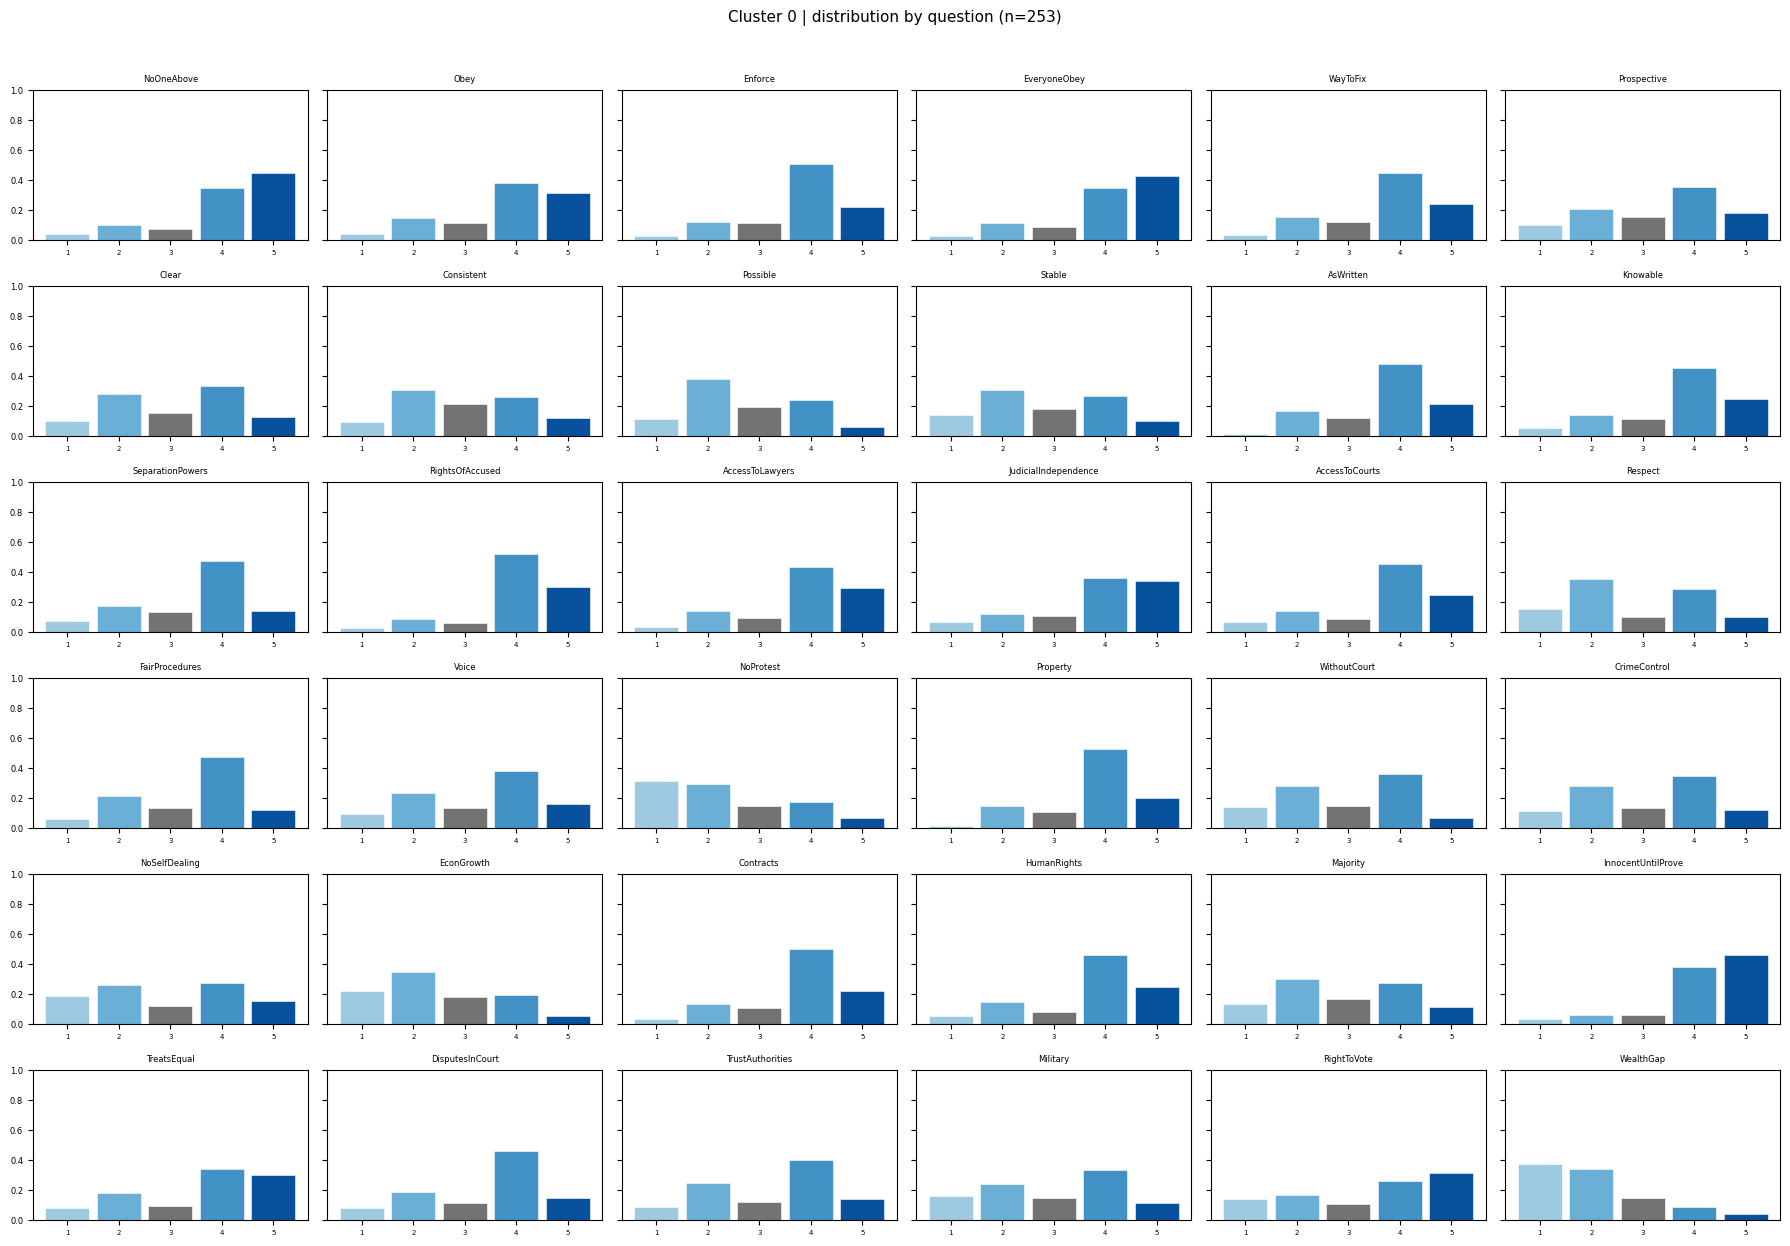

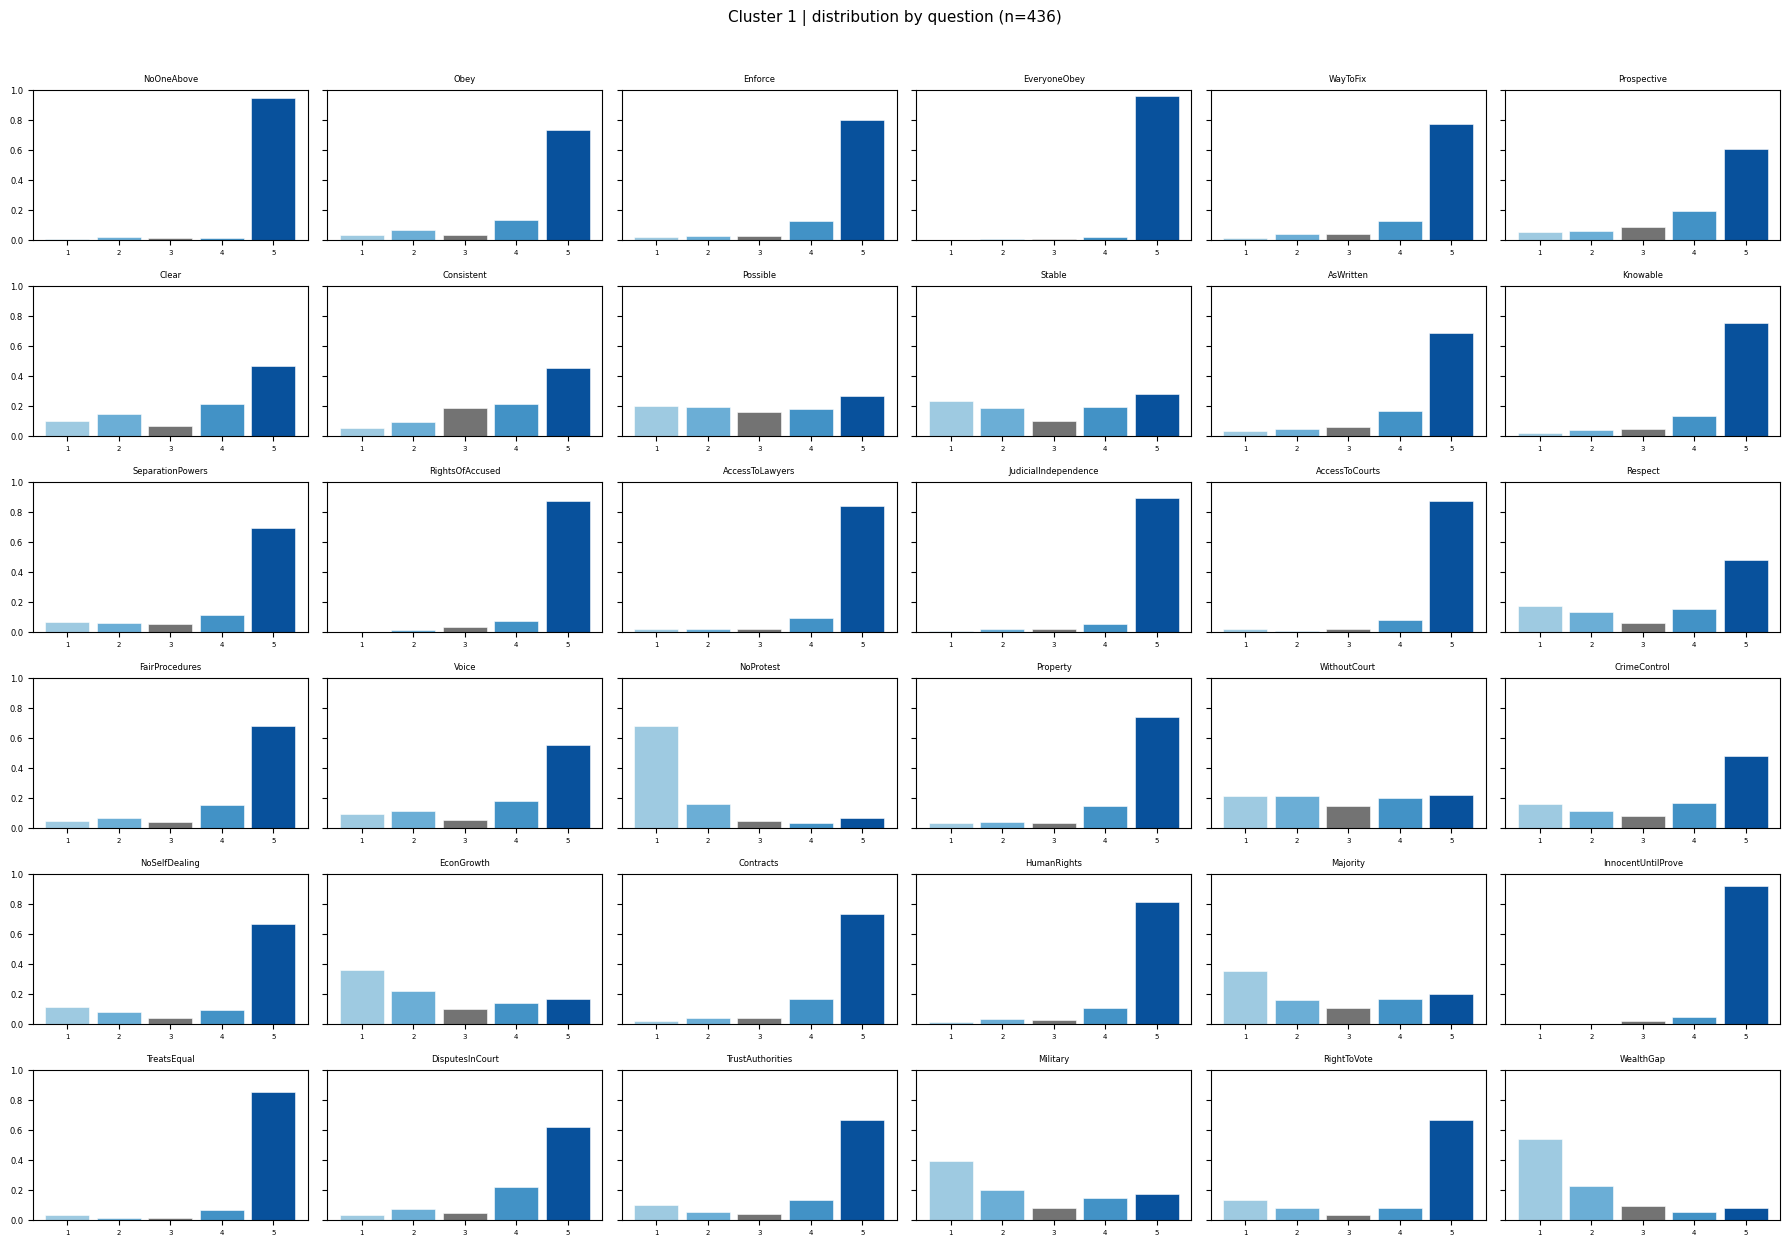

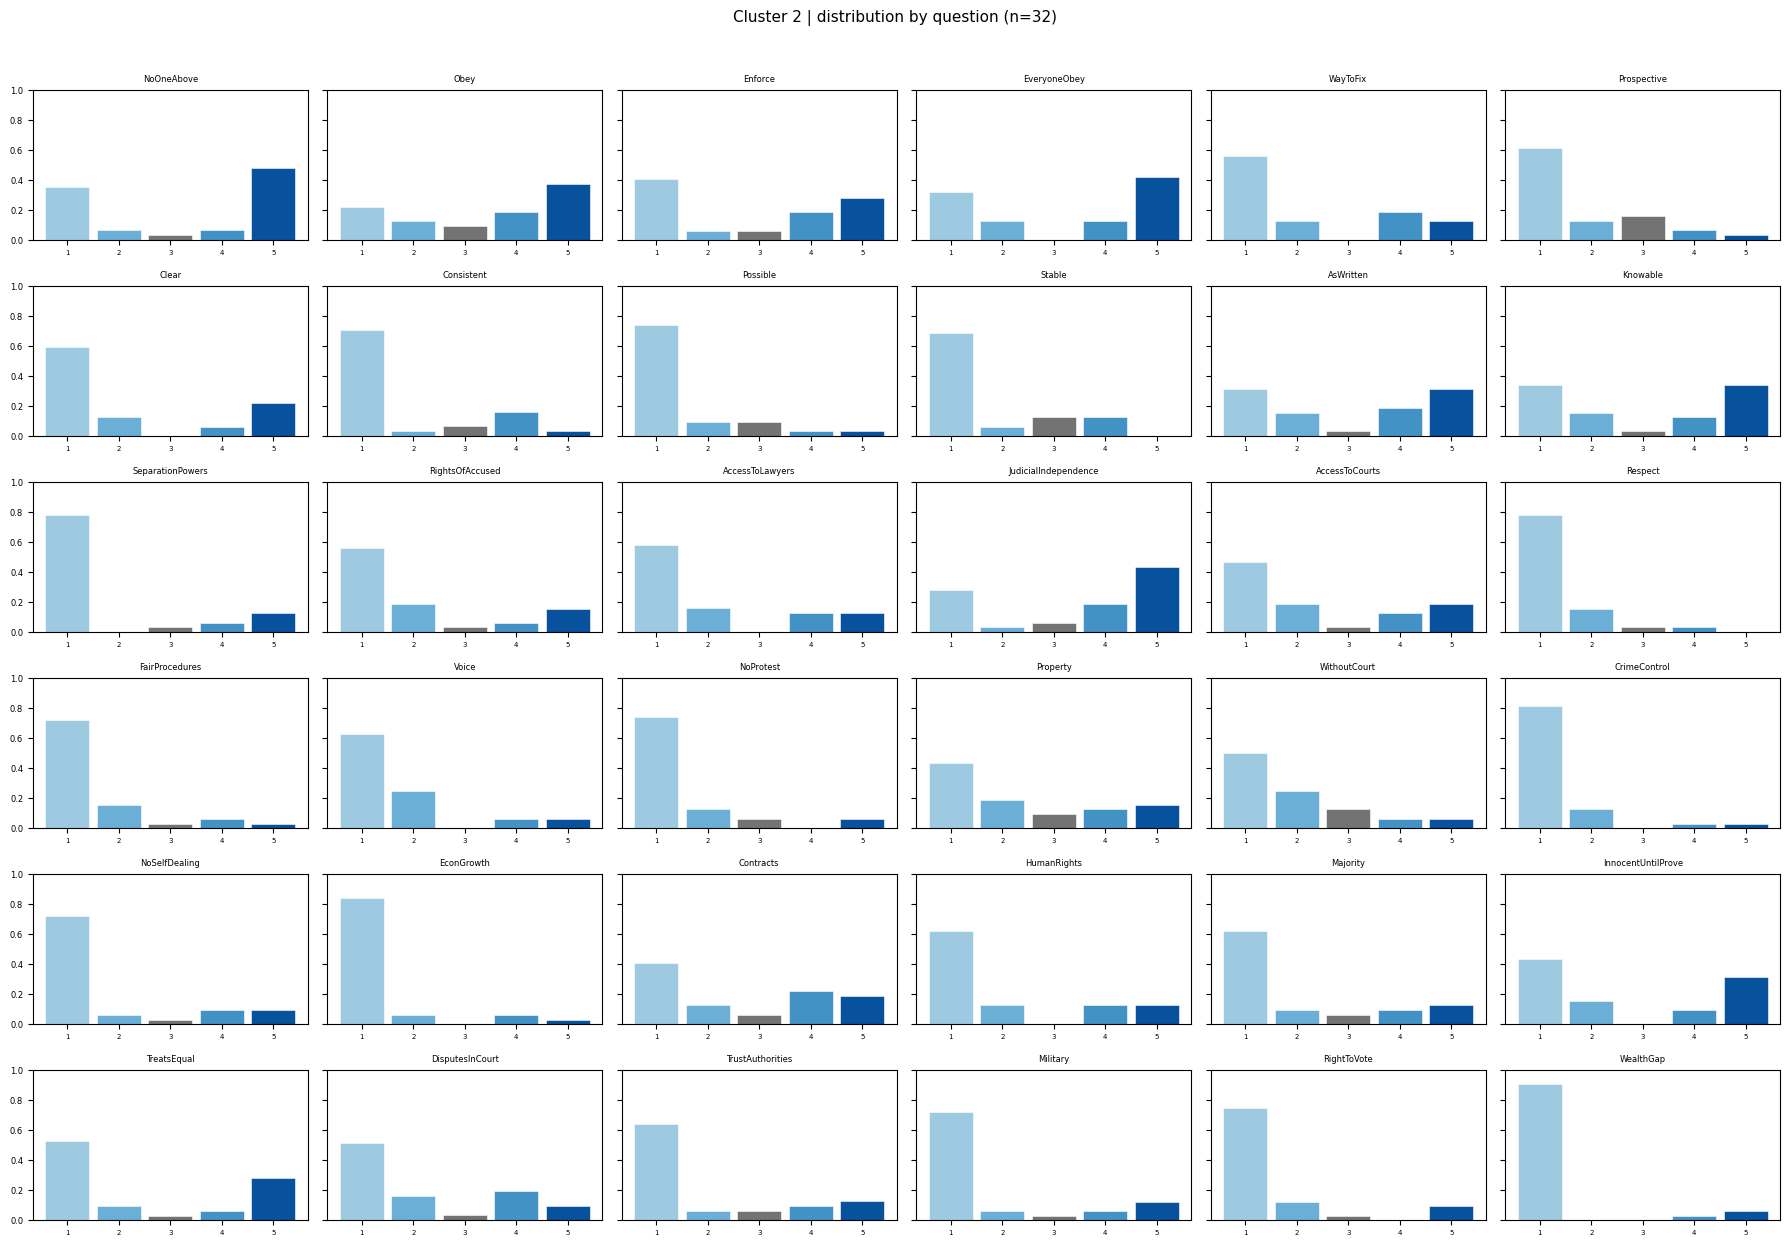

In [7]:
levels = [1, 2, 3, 4, 5]
clusters_sorted = sorted(meta["cluster_concept"].dropna().astype(int).unique().tolist())

for g in clusters_sorted:
    idx = meta.index[meta["cluster_concept"].astype(int).eq(g)]
    Xg = X.loc[idx, CONCEPT_COLS].apply(pd.to_numeric, errors="coerce")
    n_items = len(CONCEPT_COLS)
    n_cols = 6
    n_rows = int(np.ceil(n_items / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 2.1 * n_rows), sharey=True)
    axes = np.array(axes).reshape(-1)

    for j, c in enumerate(CONCEPT_COLS):
        ax = axes[j]
        s = Xg[c]
        cnt = s.value_counts(dropna=True)
        total = float(cnt.sum())
        vals = np.array([cnt.get(k, 0.0) / total if total > 0 else 0.0 for k in levels])
        colors = ["#9ecae1", "#6baed6", "#737373", "#4292c6", "#08519c"]
        ax.bar(levels, vals, color=colors, width=0.85, edgecolor="white", linewidth=0.4)
        ax.set_xticks(levels)
        ax.set_ylim(0, 1)
        ax.set_title(c, fontsize=6)
        ax.tick_params(axis="x", labelsize=5)
        ax.tick_params(axis="y", labelsize=6)

    for j in range(n_items, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Cluster {g} | distribution by question (n={len(idx)})", y=0.995, fontsize=11)
    plt.tight_layout(rect=(0, 0.01, 1, 0.98))
    plt.show()